# 01 — Data Pipeline

This notebook builds the reproducible data layer for the project.

The goal is not to optimize a strategy yet. The goal is to create a clean and auditable market data panel that will be reused by all downstream notebooks:

1. regime detection,
2. regime-conditioned risk estimation,
3. allocation backtesting,
4. SMDP-inspired stress-state policy analysis.

The notebook follows the project design principle:

> notebooks are visual research interfaces; reusable logic lives in `src/regime_portfolio`.

## Research objective

Construct a clean multi-asset ETF panel and a first interpretable feature set for regime detection.

The notebook should answer:

- Which assets define the investable universe?
- What common sample period is available after cleaning?
- Which observations are lost because of missing data or rolling-feature warm-up?
- Are daily returns and regime features numerically plausible?
- Which files are exported for downstream notebooks?

## Expected local outputs

Core pipeline outputs:

- `data/processed/prices.csv`
- `data/processed/returns.csv`
- `data/processed/risk_features.csv`

Audit and diagnostic outputs:

- `data/processed/data_quality_report.csv`
- `data/processed/return_summary.csv`
- `data/processed/extreme_return_audit.csv`
- `data/processed/feature_summary.csv`
- `data/processed/data_pipeline_manifest.csv`

Figures:

- `reports/figures/01_normalized_prices.png`
- `reports/figures/01_feature_panel.png`

Interpretation rule:

> This notebook validates the data layer. It does not make any allocation or alpha claim.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow the notebook to run both after `pip install -e .` and directly from the repo.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
from regime_portfolio.data import DataConfig, compute_returns, load_price_panel
from regime_portfolio.features import FeatureConfig, make_feature_panel

## 1. Market universe and data conventions

The default universe is deliberately simple and liquid:

| Ticker | Role |
|---|---|
| SPY | US equities |
| TLT | long-duration US Treasuries |
| IEF | intermediate US Treasuries |
| GLD | gold |
| DBC | broad commodities |
| UUP | US dollar |
| SHY | short Treasuries / defensive proxy |

This is not meant to be a final institutional universe. It is a controlled public-data universe for demonstrating the research pipeline.

In [3]:
config = DataConfig(
    tickers=("SPY", "TLT", "IEF", "GLD", "DBC", "UUP", "SHY"),
    start="2007-01-01",
    end=None,
    source="yfinance",
)

config

DataConfig(tickers=('SPY', 'TLT', 'IEF', 'GLD', 'DBC', 'UUP', 'SHY'), start='2007-01-01', end=None, source='yfinance')

## 2. Download price data

The project currently uses public ETF prices. This is convenient for a transparent GitHub research project, but the data source should be treated as a research input rather than a production-grade market data feed.

The key reproducibility rule is simple:

> downstream notebooks should read the processed CSV files produced here, not download their own inconsistent data panels.

In [4]:
prices_raw = load_price_panel(config)

print(f"Raw price panel shape: {prices_raw.shape}")
display(prices_raw.tail())

Raw price panel shape: (4892, 7)


Ticker,DBC,GLD,IEF,SHY,SPY,TLT,UUP
Date,,,,,,,
2026-06-08,29.4700,397.2700,93.5200,81.9000,739.2200,84.6200,28.0300
2026-06-09,29.0700,390.7800,93.7800,81.9400,737.0500,85.1200,28.0100
2026-06-10,29.1700,374.5800,93.6900,81.9400,725.4300,84.8800,28.0500
2026-06-11,28.8500,386.3200,94.3400,82.0900,737.7600,85.9800,27.9500
2026-06-12,28.7697,384.7700,94.0650,82.0450,740.2200,85.5050,27.9650


## 3. Basic data quality checks

Before computing returns, we inspect:

- date range,
- missing values,
- available tickers,
- first and last valid observations.

The purpose is to make data issues visible early rather than hiding them inside the backtest.

In [5]:
data_quality = pd.DataFrame(
    {
        "first_valid_date": prices_raw.apply(lambda x: x.first_valid_index()),
        "last_valid_date": prices_raw.apply(lambda x: x.last_valid_index()),
        "missing_count": prices_raw.isna().sum(),
        "missing_pct": prices_raw.isna().mean(),
    }
)

data_quality["first_valid_date"] = pd.to_datetime(data_quality["first_valid_date"])
data_quality["last_valid_date"] = pd.to_datetime(data_quality["last_valid_date"])

common_start = data_quality["first_valid_date"].max()
common_end = data_quality["last_valid_date"].min()

print("Raw data quality report")
print(f"Raw panel shape: {prices_raw.shape}")
print(f"Common start implied by latest first-valid asset: {common_start.date()}")
print(f"Common end implied by earliest last-valid asset: {common_end.date()}")

display(data_quality.sort_values("first_valid_date"))

late_start_assets = data_quality.loc[data_quality["first_valid_date"] > data_quality["first_valid_date"].min()]

if not late_start_assets.empty:
    print("\nAssets reducing the common sample period:")
    display(late_start_assets)
else:
    print("\nNo asset starts later than the earliest asset in the panel.")

Raw data quality report
Raw panel shape: (4892, 7)
Common start implied by latest first-valid asset: 2007-03-01
Common end implied by earliest last-valid asset: 2026-06-12


,first_valid_date,last_valid_date,missing_count,missing_pct
Ticker,,,,
DBC,2007-01-03,2026-06-12,0,0.0000
GLD,2007-01-03,2026-06-12,0,0.0000
IEF,2007-01-03,2026-06-12,0,0.0000
SHY,2007-01-03,2026-06-12,0,0.0000
SPY,2007-01-03,2026-06-12,0,0.0000
TLT,2007-01-03,2026-06-12,0,0.0000
UUP,2007-03-01,2026-06-12,39,0.0080



Assets reducing the common sample period:


,first_valid_date,last_valid_date,missing_count,missing_pct
Ticker,,,,
UUP,2007-03-01,2026-06-12,39,0.0080


## 4. Clean the price panel

We use a conservative cleaning convention:

1. sort the date index,
2. remove rows where all assets are missing,
3. forward-fill short gaps,
4. keep only rows where all selected assets are available.

This creates a common trading calendar for all assets. That is useful for this first research version because regime features, correlations, and allocation weights all need aligned observations.

In [6]:
prices = (
    prices_raw
    .sort_index()
    .dropna(how="all")
    .ffill()
    .dropna(how="any")
)

print(f"Clean price panel shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
display(prices.tail())

Clean price panel shape: (4853, 7)
Date range: 2007-03-01 to 2026-06-12


Ticker,DBC,GLD,IEF,SHY,SPY,TLT,UUP
Date,,,,,,,
2026-06-08,29.4700,397.2700,93.5200,81.9000,739.2200,84.6200,28.0300
2026-06-09,29.0700,390.7800,93.7800,81.9400,737.0500,85.1200,28.0100
2026-06-10,29.1700,374.5800,93.6900,81.9400,725.4300,84.8800,28.0500
2026-06-11,28.8500,386.3200,94.3400,82.0900,737.7600,85.9800,27.9500
2026-06-12,28.7697,384.7700,94.0650,82.0450,740.2200,85.5050,27.9650


## 4.1 Cleaning audit

The cleaned panel keeps only dates where all selected assets are available after forward filling.

This is a deliberate choice for the first project version because downstream covariance estimates, feature construction, regime detection, and allocation weights all require a common calendar.

The main expected loss comes from assets that start later than the rest of the universe.

In [7]:
raw_nonempty = prices_raw.sort_index().dropna(how="all")
cleaning_audit = pd.Series(
    {
        "raw_rows_after_drop_all_missing": len(raw_nonempty),
        "clean_rows": len(prices),
        "rows_removed_by_common_calendar": len(raw_nonempty) - len(prices),
        "raw_start": raw_nonempty.index.min().date(),
        "raw_end": raw_nonempty.index.max().date(),
        "clean_start": prices.index.min().date(),
        "clean_end": prices.index.max().date(),
        "n_assets": prices.shape[1],
    },
    name="value",
)

display(cleaning_audit.to_frame())

removed_dates = raw_nonempty.index.difference(prices.index)

if len(removed_dates) > 0:
    removed_dates_preview = pd.DataFrame(
        {
            "removed_date": removed_dates[:10],
            "note": "Removed because at least one asset was unavailable on the common cleaned calendar.",
        }
    )
    print(f"Number of removed dates: {len(removed_dates)}")
    display(removed_dates_preview)
else:
    print("No dates were removed by the common-calendar cleaning rule.")

,value
raw_rows_after_drop_all_missing,4892
clean_rows,4853
rows_removed_by_common_calendar,39
raw_start,2007-01-03
raw_end,2026-06-12
clean_start,2007-03-01
clean_end,2026-06-12
n_assets,7


Number of removed dates: 39


,removed_date,note
0,2007-01-03,Removed because at least one asset was unavail...
1,2007-01-04,Removed because at least one asset was unavail...
2,2007-01-05,Removed because at least one asset was unavail...
3,2007-01-08,Removed because at least one asset was unavail...
4,2007-01-09,Removed because at least one asset was unavail...
5,2007-01-10,Removed because at least one asset was unavail...
6,2007-01-11,Removed because at least one asset was unavail...
7,2007-01-12,Removed because at least one asset was unavail...
8,2007-01-16,Removed because at least one asset was unavail...
9,2007-01-17,Removed because at least one asset was unavail...


## 5. Compute daily log returns

The project uses log returns as the default convention. Log returns are convenient for cumulative performance diagnostics because cumulative log returns exponentiate into a wealth index.

This notebook only prepares returns. It does not decide whether a trading rule is good.

In [8]:
returns = compute_returns(prices, method="log", dropna=True)

return_summary = returns.describe().T
return_summary["ann_return_approx"] = returns.mean() * 252
return_summary["ann_vol"] = returns.std(ddof=1) * np.sqrt(252)
return_summary["max_abs_daily_return"] = returns.abs().max()
return_summary["max_abs_daily_return_date"] = returns.abs().idxmax()

ordered_columns = [
    "count",
    "mean",
    "std",
    "ann_return_approx",
    "ann_vol",
    "min",
    "25%",
    "50%",
    "75%",
    "max",
    "max_abs_daily_return",
    "max_abs_daily_return_date",
]

return_summary = return_summary[ordered_columns]

print(f"Return panel shape: {returns.shape}")
print(f"Date range: {returns.index.min().date()} to {returns.index.max().date()}")

display(return_summary)

Return panel shape: (4852, 7)
Date range: 2007-03-02 to 2026-06-12


,count,mean,std,ann_return_approx,ann_vol,min,25%,50%,75%,max,max_abs_daily_return,max_abs_daily_return_date
Ticker,,,,,,,,,,,,
DBC,"4,852.0000",0.0001,0.0121,0.0180,0.1929,-0.0828,-0.0062,0.0007,0.0067,0.0665,0.0828,2022-03-09
GLD,"4,852.0000",0.0004,0.0114,0.0917,0.1809,-0.1084,-0.0051,0.0006,0.0062,0.1070,0.1084,2026-01-30
IEF,"4,852.0000",0.0001,0.0044,0.0316,0.0696,-0.0254,-0.0025,0.0002,0.0027,0.0337,0.0337,2009-03-18
SHY,"4,852.0000",0.0001,0.0010,0.0183,0.0152,-0.0066,-0.0004,0.0000,0.0005,0.0099,0.0099,2023-03-13
SPY,"4,852.0000",0.0004,0.0124,0.1047,0.1971,-0.1159,-0.0041,0.0007,0.0060,0.1356,0.1356,2008-10-13
TLT,"4,852.0000",0.0001,0.0095,0.0285,0.1512,-0.0690,-0.0056,0.0004,0.0057,0.0725,0.0725,2020-03-20
UUP,"4,852.0000",0.0001,0.0051,0.0160,0.0809,-0.0386,-0.0028,0.0000,0.0029,0.0398,0.0398,2007-06-21


## 5.1 Extreme-return audit

Large daily moves can dominate rolling volatility, downside semivolatility, and regime detection.

This table does not remove observations. It simply identifies the largest absolute daily log return for each asset and records the corresponding price movement.

The purpose is data governance: unusually large moves should be visible before they affect regime detection.

In [9]:
extreme_return_rows = []

for asset in returns.columns:
    date = returns[asset].abs().idxmax()
    previous_date_position = prices.index.get_loc(date) - 1

    if previous_date_position >= 0:
        previous_date = prices.index[previous_date_position]
        previous_price = prices.loc[previous_date, asset]
    else:
        previous_date = pd.NaT
        previous_price = np.nan

    current_price = prices.loc[date, asset]

    extreme_return_rows.append(
        {
            "asset": asset,
            "date": date,
            "return": returns.loc[date, asset],
            "abs_return": abs(returns.loc[date, asset]),
            "previous_date": previous_date,
            "previous_price": previous_price,
            "current_price": current_price,
            "simple_price_change": current_price / previous_price - 1.0
            if pd.notna(previous_price) and previous_price != 0
            else np.nan,
        }
    )

extreme_return_audit = (
    pd.DataFrame(extreme_return_rows)
    .sort_values("abs_return", ascending=False)
    .reset_index(drop=True)
)

display(extreme_return_audit)

large_move_threshold = 0.05

large_move_counts = (
    (returns.abs() >= large_move_threshold)
    .sum()
    .rename(f"n_abs_daily_returns_above_{large_move_threshold:.0%}")
    .sort_values(ascending=False)
)

display(large_move_counts.to_frame())

,asset,date,return,abs_return,previous_date,previous_price,current_price,simple_price_change
0,SPY,2008-10-13,0.1356,0.1356,2008-10-10,64.1985,73.5200,0.1452
1,GLD,2026-01-30,-0.1084,0.1084,2026-01-29,495.9000,444.9500,-0.1027
2,DBC,2022-03-09,-0.0828,0.0828,2022-03-08,24.4248,22.4844,-0.0794
3,TLT,2020-03-20,0.0725,0.0725,2020-03-19,123.0057,132.2552,0.0752
4,UUP,2007-06-21,0.0398,0.0398,2007-06-20,19.8497,20.6562,0.0406
5,IEF,2009-03-18,0.0337,0.0337,2009-03-17,62.8270,64.9797,0.0343
6,SHY,2023-03-13,0.0099,0.0099,2023-03-10,72.1623,72.8820,0.0100


,n_abs_daily_returns_above_5%
Ticker,
SPY,36
DBC,16
GLD,15
TLT,8
IEF,0
SHY,0
UUP,0


## 6. Build interpretable regime features

The first version of the project uses a compact feature set:

- realized volatility of the equity proxy,
- rolling drawdown of the equity proxy,
- rolling average cross-asset correlation,
- equity momentum,
- downside semivolatility.

These features are intentionally interpretable. The goal is not to maximize classification accuracy, but to produce economically meaningful stress states that can be audited.

In [10]:
feature_config = FeatureConfig(
    vol_window=21,
    corr_window=63,
    drawdown_window=252,
    momentum_window=63,
    annualization=252,
    equity_proxy="SPY",
)

risk_features = make_feature_panel(
    prices=prices,
    returns=returns,
    config=feature_config,
)

feature_coverage = pd.Series(
    {
        "return_rows": len(returns),
        "feature_rows": len(risk_features),
        "rows_lost_to_feature_warmup": len(returns) - len(risk_features),
        "feature_start": risk_features.index.min().date(),
        "feature_end": risk_features.index.max().date(),
        "n_features": risk_features.shape[1],
    },
    name="value",
)

feature_summary = risk_features.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

feature_missing = risk_features.isna().sum().rename("missing_count").to_frame()
feature_missing["missing_pct"] = risk_features.isna().mean()

print(f"Feature panel shape: {risk_features.shape}")
display(feature_coverage.to_frame())
display(feature_summary)
display(feature_missing)
display(risk_features.tail())

Feature panel shape: (4790, 5)


,value
return_rows,4852
feature_rows,4790
rows_lost_to_feature_warmup,62
feature_start,2007-05-31
feature_end,2026-06-12
n_features,5


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
SPY_realized_vol,"4,790.0000",0.1633,0.1139,0.0342,0.0519,0.0637,0.0978,0.1339,0.1923,0.3251,0.7547,0.9367
SPY_drawdown,"4,790.0000",-0.0559,0.0867,-0.5148,-0.4119,-0.2246,-0.0701,-0.0199,-0.0034,0.0000,0.0000,0.0000
avg_corr,"4,790.0000",0.0559,0.0513,-0.0639,-0.0434,-0.0207,0.0178,0.0486,0.0918,0.1459,0.1892,0.2093
SPY_momentum,"4,790.0000",0.0289,0.0783,-0.4147,-0.2439,-0.1083,-0.0065,0.0410,0.0754,0.1273,0.1941,0.3994
SPY_downside_semivol,"4,790.0000",0.1032,0.0661,0.0205,0.0250,0.0441,0.0648,0.0847,0.1201,0.2227,0.3895,0.4393


,missing_count,missing_pct
SPY_realized_vol,0,0.0000
SPY_drawdown,0,0.0000
avg_corr,0,0.0000
SPY_momentum,0,0.0000
SPY_downside_semivol,0,0.0000


,SPY_realized_vol,SPY_drawdown,avg_corr,SPY_momentum,SPY_downside_semivol
Date,,,,,
2026-06-08,0.1290,-0.0268,0.1140,0.0928,0.0872
2026-06-09,0.1263,-0.0296,0.1145,0.0914,0.0872
2026-06-10,0.1373,-0.0449,0.1172,0.0755,0.0909
2026-06-11,0.1504,-0.0287,0.1251,0.1107,0.0876
2026-06-12,0.1495,-0.0255,0.1251,0.1207,0.0876


## 7. Visual check — normalized prices

This figure is a data sanity check, not a performance claim.

It shows the growth of one dollar invested in each ETF at the beginning of the cleaned sample. Large differences across assets are expected because the universe mixes equities, bonds, gold, commodities, USD, and short Treasuries.

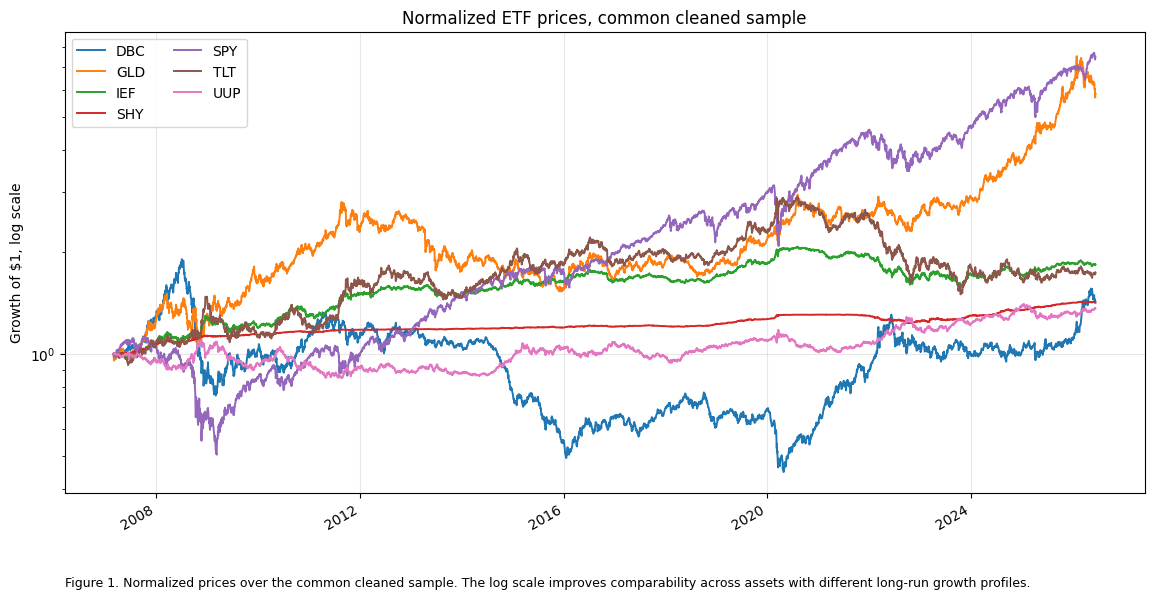

In [11]:
normalized_prices = prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))
normalized_prices.plot(ax=ax, linewidth=1.4)

ax.set_title("Normalized ETF prices, common cleaned sample")
ax.set_ylabel("Growth of $1, log scale")
ax.set_xlabel("")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", ncols=2)

caption = (
    "Figure 1. Normalized prices over the common cleaned sample. "
    "The log scale improves comparability across assets with different long-run growth profiles."
)

ax.text(
    0.0,
    -0.18,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_normalized_prices.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Visual check — regime feature panel

The next plot checks whether the constructed features behave plausibly over time. In particular, stress-related features should move during known crisis windows, but the notebook does not manually label or hard-code crisis periods.

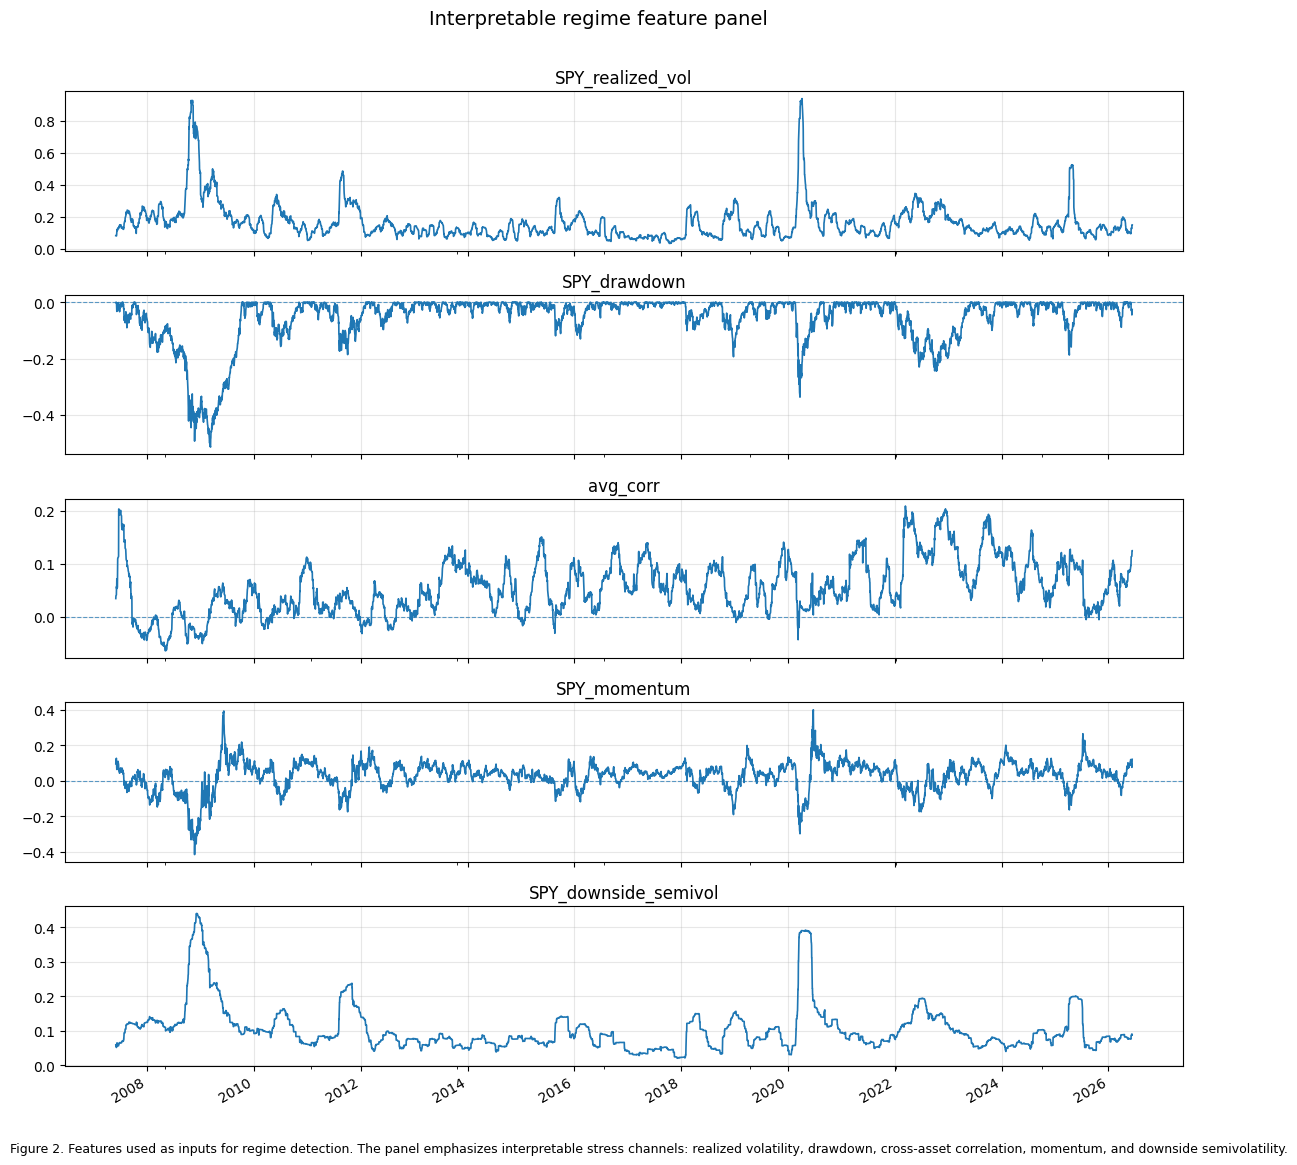

In [12]:
feature_plot = risk_features.copy()

fig, axes = plt.subplots(
    nrows=len(feature_plot.columns),
    ncols=1,
    figsize=(12, 2.2 * len(feature_plot.columns)),
    sharex=True,
)

if len(feature_plot.columns) == 1:
    axes = [axes]

for ax, column in zip(axes, feature_plot.columns):
    feature_plot[column].plot(ax=ax, linewidth=1.2)

    lower_name = column.lower()
    if any(key in lower_name for key in ["drawdown", "momentum", "corr"]):
        ax.axhline(0.0, linewidth=0.8, linestyle="--", alpha=0.7)

    ax.set_title(column)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("")

fig.suptitle("Interpretable regime feature panel", y=1.01, fontsize=14)

caption = (
    "Figure 2. Features used as inputs for regime detection. "
    "The panel emphasizes interpretable stress channels: realized volatility, drawdown, "
    "cross-asset correlation, momentum, and downside semivolatility."
)

fig.text(
    0.01,
    -0.02,
    caption,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_feature_panel.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Export processed data

All downstream notebooks should read these exported files.

This keeps the project pipeline coherent:

```text
01_data_pipeline
  -> prices.csv
  -> returns.csv
  -> risk_features.csv

In [13]:
prices.to_csv(DATA_DIR / "prices.csv")
returns.to_csv(DATA_DIR / "returns.csv")
risk_features.to_csv(DATA_DIR / "risk_features.csv")

data_quality.to_csv(DATA_DIR / "data_quality_report.csv")
return_summary.to_csv(DATA_DIR / "return_summary.csv")
extreme_return_audit.to_csv(DATA_DIR / "extreme_return_audit.csv", index=False)
feature_summary.to_csv(DATA_DIR / "feature_summary.csv")

artifact_manifest = pd.DataFrame(
    [
        {
            "artifact": "prices.csv",
            "path": str(DATA_DIR / "prices.csv"),
            "rows": prices.shape[0],
            "columns": prices.shape[1],
            "start_date": prices.index.min().date(),
            "end_date": prices.index.max().date(),
            "purpose": "Cleaned price panel used by all downstream notebooks.",
        },
        {
            "artifact": "returns.csv",
            "path": str(DATA_DIR / "returns.csv"),
            "rows": returns.shape[0],
            "columns": returns.shape[1],
            "start_date": returns.index.min().date(),
            "end_date": returns.index.max().date(),
            "purpose": "Daily log returns used for risk estimation and backtesting.",
        },
        {
            "artifact": "risk_features.csv",
            "path": str(DATA_DIR / "risk_features.csv"),
            "rows": risk_features.shape[0],
            "columns": risk_features.shape[1],
            "start_date": risk_features.index.min().date(),
            "end_date": risk_features.index.max().date(),
            "purpose": "Interpretable regime features used by the regime-detection notebook.",
        },
        {
            "artifact": "data_quality_report.csv",
            "path": str(DATA_DIR / "data_quality_report.csv"),
            "rows": data_quality.shape[0],
            "columns": data_quality.shape[1],
            "start_date": None,
            "end_date": None,
            "purpose": "Asset-level availability and missing-data audit.",
        },
        {
            "artifact": "return_summary.csv",
            "path": str(DATA_DIR / "return_summary.csv"),
            "rows": return_summary.shape[0],
            "columns": return_summary.shape[1],
            "start_date": None,
            "end_date": None,
            "purpose": "Return distribution and annualized diagnostic summary.",
        },
        {
            "artifact": "extreme_return_audit.csv",
            "path": str(DATA_DIR / "extreme_return_audit.csv"),
            "rows": extreme_return_audit.shape[0],
            "columns": extreme_return_audit.shape[1],
            "start_date": None,
            "end_date": None,
            "purpose": "Largest absolute daily return by asset for data-governance review.",
        },
        {
            "artifact": "feature_summary.csv",
            "path": str(DATA_DIR / "feature_summary.csv"),
            "rows": feature_summary.shape[0],
            "columns": feature_summary.shape[1],
            "start_date": None,
            "end_date": None,
            "purpose": "Summary statistics for the regime-feature panel.",
        },
    ]
)

artifact_manifest.to_csv(DATA_DIR / "data_pipeline_manifest.csv", index=False)

print("Saved core pipeline outputs:")
print(DATA_DIR / "prices.csv")
print(DATA_DIR / "returns.csv")
print(DATA_DIR / "risk_features.csv")

print("\nSaved audit outputs:")
print(DATA_DIR / "data_quality_report.csv")
print(DATA_DIR / "return_summary.csv")
print(DATA_DIR / "extreme_return_audit.csv")
print(DATA_DIR / "feature_summary.csv")
print(DATA_DIR / "data_pipeline_manifest.csv")

display(artifact_manifest)

Saved core pipeline outputs:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/prices.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/returns.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/risk_features.csv

Saved audit outputs:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/data_quality_report.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/return_summary.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/extreme_return_audit.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/feature_summary.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/data_pipeline_manifest.csv


,artifact,path,rows,columns,start_date,end_date,purpose
0,prices.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4853,7,2007-03-01,2026-06-12,Cleaned price panel used by all downstream not...
1,returns.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4852,7,2007-03-02,2026-06-12,Daily log returns used for risk estimation and...
2,risk_features.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4790,5,2007-05-31,2026-06-12,Interpretable regime features used by the regi...
3,data_quality_report.csv,/workspaces/regime-aware-portfolio-risk-alloca...,7,4,None,None,Asset-level availability and missing-data audit.
4,return_summary.csv,/workspaces/regime-aware-portfolio-risk-alloca...,7,12,None,None,Return distribution and annualized diagnostic ...
5,extreme_return_audit.csv,/workspaces/regime-aware-portfolio-risk-alloca...,7,8,None,None,Largest absolute daily return by asset for dat...
6,feature_summary.csv,/workspaces/regime-aware-portfolio-risk-alloca...,5,12,None,None,Summary statistics for the regime-feature panel.


## 10. Notebook takeaway

This notebook creates the common data layer for the project.

Main outputs:

- a cleaned cross-asset ETF price panel,
- a daily log-return panel,
- an interpretable regime-feature panel,
- audit tables documenting missing data, feature warm-up loss, and extreme daily moves.

Key data decisions:

1. The cleaned sample uses a common calendar across all assets.
2. The common start date is determined by the latest-starting asset in the selected universe.
3. Returns are computed as daily log returns.
4. Regime features are deliberately interpretable rather than high-dimensional.
5. Extreme observations are audited but not removed.

The next notebook uses the feature panel to estimate ordered latent regimes.

At this stage, no allocation rule has been evaluated and no alpha claim has been made.